### Note: Ini cuman buat hint aja ya, klo mau pake file ini buat ngejurnal ngga apa apa

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

import numpy untuk mengolah data atau nilai piksel yg berbentuk array atau matriks.

import cv2 digunakan untuk mengimport library OpenCV. penggunaan library dalam kode ini digunakan untuk mengubah warna menjadi abu atau grayscale.

import matplotlib.pyplot as plt digunakan untuk memanggil modul pyplot dari library Matplotlib dengan alias plt. Modul ini berfungsi untuk menampilkan visualisasi, seperti gambar dan grafik.

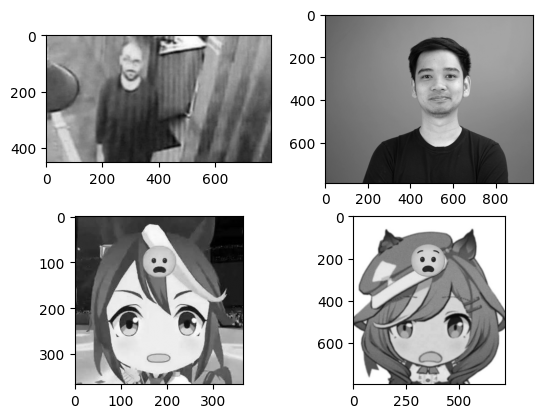

In [47]:
backup = cv2.cvtColor(cv2.imread('backup.jpg'), cv2.COLOR_BGR2GRAY)
david = cv2.cvtColor(cv2.imread('david.jpg'), cv2.COLOR_BGR2GRAY)
hachimi = cv2.cvtColor(cv2.imread('hachimi.jpeg'), cv2.COLOR_BGR2GRAY)
mambo = cv2.cvtColor(cv2.imread('mambo.jpeg'), cv2.COLOR_BGR2GRAY)

plt.subplot(2,2,1)
plt.imshow(backup, cmap='gray')
plt.subplot(2,2,2)
plt.imshow(david, cmap='gray')
plt.subplot(2,2,3)
plt.imshow(hachimi, cmap='gray')
plt.subplot(2,2,4)
plt.imshow(mambo, cmap='gray')

plt.show()

ini buat nunjukin semua gambar grayscale biar sekalian makanya semuanya saya lgsg tampilin gambarnya

In [48]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size*size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total = 0
                    for val in region.ravel():
                        total+=int(val)
                    canvas[i, j] = total / area

        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = np.sort(region.ravel())
                    canvas[i, j] = values[len(values) // 2]
        
        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i,j] = mode_val
    return canvas

#cara panggil
#hasil = filter(foto_bla, 3, 'mean')

ini fungsi buat mean, modus, sama median. nanti fungsi ini dipanggil buat mencari mean, modus, sama mediannya.

In [49]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img,pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i,j] = np.sum(region * kernel)
    return canvas

#cara panggil
#hasil = convolution(fotoMarsha, kernel)

ini fungsi konvolusi buat ngerubah gambar jadi sharpening dan smoothing, nanti dipanggil dibawah

In [50]:
#kernel penghalus gambar
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5, 1/10],
    [1/10, 1/10, 1/10]
])

#kernel penajam gambar
kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

ini kernel buat penghalus gambar dan penajam gambar

In [51]:
#kernel sobel sumbu x
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

#kernel sobel sumbu y
sobelY = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

kernel sobel ada yg kernel sumbu x dan kernel sumbu y

In [52]:
#kernel prewitt sumbu x
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

#kernel prewitt sumbu y
prewittY = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

kernel prewitt juga sama kyk kernel sobel cuman kernelnya prewitt seragam angkanya

In [63]:
#kernel roberts sumbu x
robertsX = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

#kernel sobel sumbu y
robertsY = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

roberts kernelnya 2x2 sama juga ada yg sumbu x sama sumbu y

In [64]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

#cara panggil
#hasil_tepi = edge(fotoTania, prewittX, prewittY)

ini fungsi edge, buat manggil hasil tepi dari operator prewitt, sobel, sama roberts. gx dan gy buat kernel sumbu x dan y

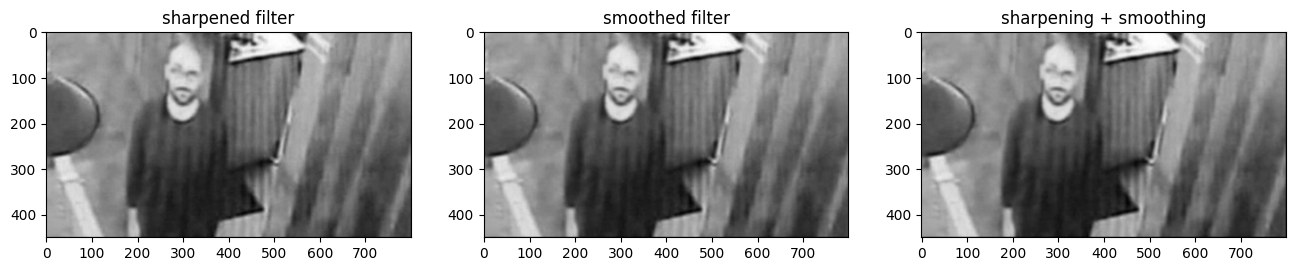

In [65]:
sharpening = convolution(backup, kernelSharpening)
smoothing = convolution(backup, kernelSmoothing)
smootsharp = convolution(smoothing+sharpening, kernelSharpening)

plt.figure(figsize=(16,8))
plt.subplot(2,3,1)
plt.title("sharpened filter")
plt.imshow(sharpening, cmap='gray')
plt.subplot(2,3,2)
plt.title("smoothed filter")
plt.imshow(smoothing, cmap='gray')
plt.subplot(2,3,3)
plt.imshow(smootsharp, cmap="gray")
plt.title("sharpening + smoothing")
plt.show()

ini hasil sharpening, smoothing dan juga sharpening+smoothing untuk gambar backup. sharpening buat pertajam gambar trs smoothing buat perhalus gambarnya trs digabung jadi gambarnya dipertajam dan diperhalus.

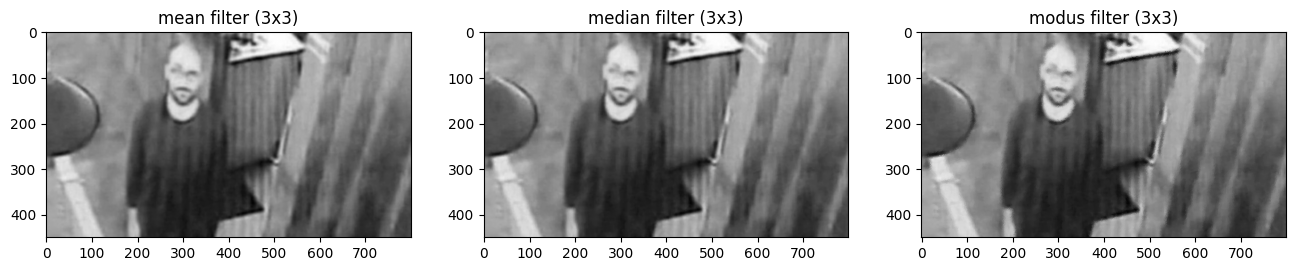

In [74]:
mean3x3 = filter(backup, 3, 'mean')
median3x3 = filter(backup, 3, 'median')
modus3x3 = filter(backup, 3, 'modus')

plt.figure(figsize=(16,8))
plt.subplot(2,3,1)
plt.title("mean filter (3x3)")
plt.imshow(mean3x3, cmap='gray')
plt.subplot(2,3,2)
plt.title("median filter (3x3)")
plt.imshow(median3x3, cmap='gray')
plt.subplot(2,3,3)
plt.title("modus filter (3x3)")
plt.imshow(modus3x3, cmap='gray')
plt.show()

buat memanipulasi citra berdasarkan piksel sekitarnya, rata-rata (mean) untuk menghaluskan gambar, nilai tengah (median) untuk membersihkan bintik tajam tanpa merusak tepi, dan modus (mode) untuk menyeragamkan warna dominan sehingga
tampak seperti poster.

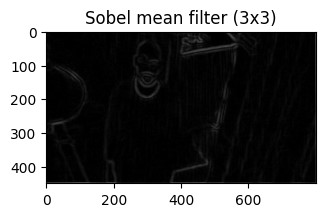

In [67]:
sobel_mean3 = edge(mean3x3, sobelX, sobelY)

plt.figure(figsize=(16,8))
plt.subplot(2,4,1)
plt.title("Sobel mean filter (3x3)")
plt.imshow(sobel_mean3, cmap='gray')
plt.show()

deteksi tepi dengan sobel dengan kernel 3x3 sumbu x dan sumbu y 

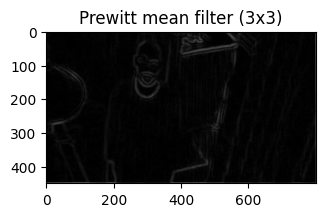

In [68]:
prewitt_mean3 = edge(mean3x3, prewittX, prewittY)

plt.figure(figsize=(16,8))
plt.subplot(2,4,1)
plt.title("Prewitt mean filter (3x3)")
plt.imshow(prewitt_mean3, cmap='gray')
plt.show()

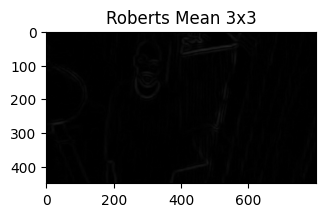

In [69]:
roberts_mean3x3 = edge(mean3x3, robertsX, robertsY)

plt.figure(figsize=(16,8))
plt.subplot(2,4,1)
plt.imshow(roberts_mean3x3, cmap='gray')
plt.title('Roberts Mean 3x3')
plt.show()

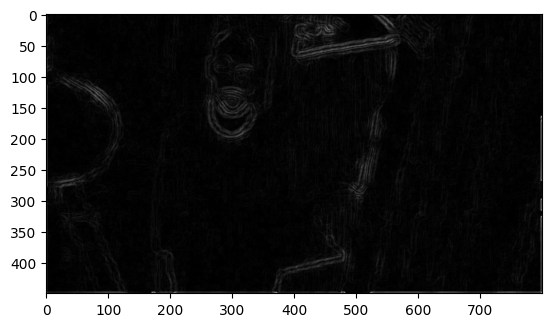

In [70]:
prewittSobel = edge(sobel_mean3+prewitt_mean3, sobelX, sobelY)

plt.imshow(prewittSobel, cmap="gray")
plt.show()

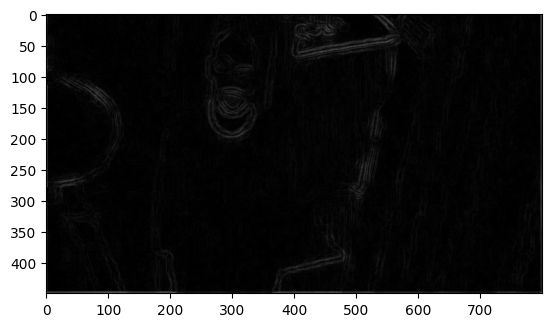

In [75]:
sobelRoberts = edge(sobel_mean3+roberts_mean3x3, sobelX, sobelY)

plt.imshow(sobelRoberts, cmap='gray')
plt.show()

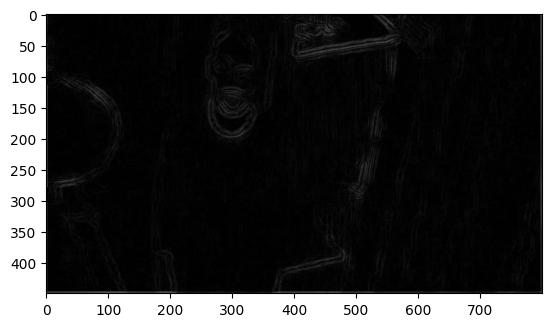

In [76]:
prewittRoberts = edge(prewitt_mean3+roberts_mean3x3, prewittX, prewittY)

plt.imshow(prewittRoberts, cmap='gray')
plt.show()

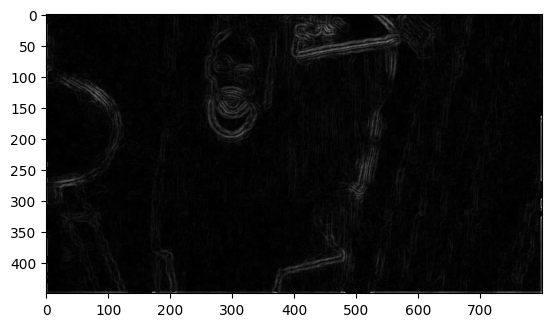

In [77]:
prerobel = edge(prewitt_mean3+sobel_mean3+roberts_mean3x3, sobelX, sobelY)

plt.imshow(prerobel, cmap='gray')
plt.show()

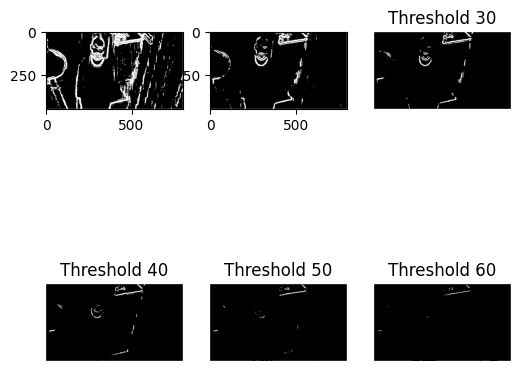

In [78]:
nilai_thresholding10 = 10
nilai_thresholding20 = 20
nilai_thresholding30 = 30
nilai_thresholding40 = 40
nilai_thresholding50 = 50
nilai_thresholding60 = 60

tresh10 = np.where(prewitt_mean3 >= nilai_thresholding10, 255, 0).astype(np.uint8)
tresh20 = np.where(prewitt_mean3 >= nilai_thresholding20, 255, 0).astype(np.uint8)
tresh30 = np.where(prewitt_mean3 >= nilai_thresholding30, 255, 0).astype(np.uint8)
tresh40 = np.where(prewitt_mean3 >= nilai_thresholding40, 255, 0).astype(np.uint8)
tresh50 = np.where(prewitt_mean3 >= nilai_thresholding50, 255, 0).astype(np.uint8)
tresh60 = np.where(prewitt_mean3 >= nilai_thresholding60, 255, 0).astype(np.uint8)

plt.figure(figsize=(6,6))

plt.subplot(2,3,1)
plt.imshow(tresh10, cmap='gray')

plt.subplot(2,3,2)
plt.imshow(tresh20, cmap='gray')

plt.subplot(2,3,3)
plt.imshow(tresh30, cmap='gray')
plt.title("Threshold 30")
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(tresh40, cmap='gray')
plt.title("Threshold 40")
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(tresh50, cmap='gray')
plt.title("Threshold 50")
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(tresh60, cmap='gray')
plt.title("Threshold 60")
plt.axis('off')
plt.show()

Text(0.5, 1.0, 'Median 9x9')

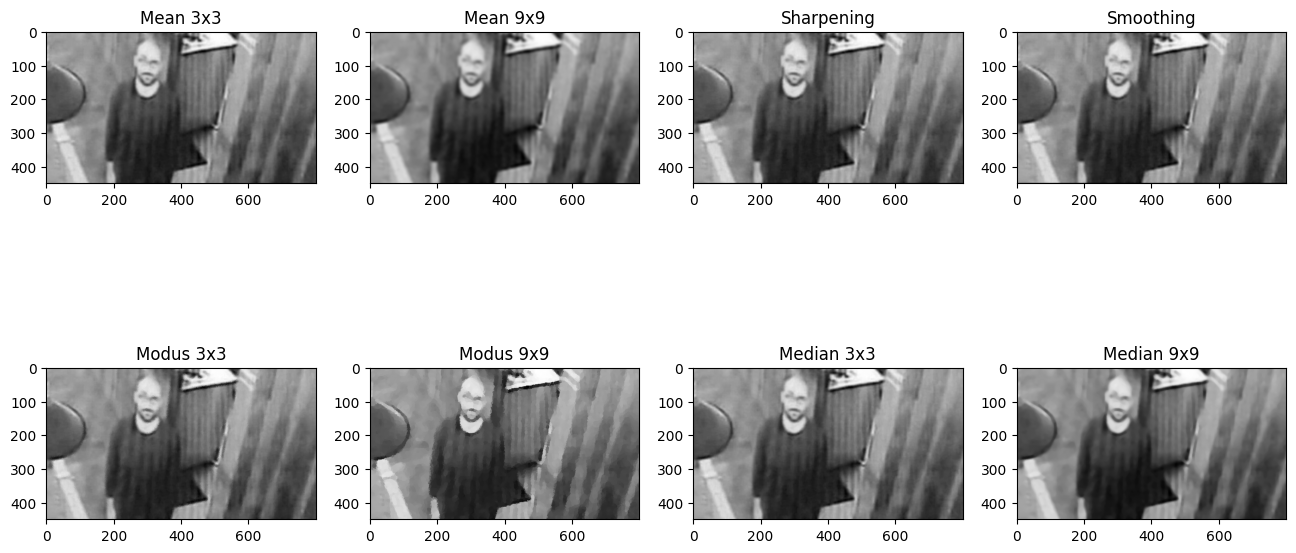

In [71]:
plt.figure(figsize=(16,8))
plt.subplot(2,4,1)
plt.imshow(mean3x3, cmap='gray')
plt.title('Mean 3x3')
plt.subplot(2,4,2)
plt.imshow(mean9x9, cmap='gray')
plt.title('Mean 9x9')
plt.subplot(2,4,3)
plt.imshow(sharpening, cmap='gray')
plt.title('Sharpening')
plt.subplot(2,4,4)
plt.imshow(smoothing, cmap='gray')
plt.title('Smoothing')
plt.subplot(2,4,5)
plt.imshow(modus3x3, cmap='gray')
plt.title('Modus 3x3')
plt.subplot(2,4,6)
plt.imshow(modus9x9, cmap='gray')
plt.title('Modus 9x9')
plt.subplot(2,4,7)
plt.imshow(median3x3, cmap='gray')
plt.title('Median 3x3')
plt.subplot(2,4,8)
plt.imshow(median9x9, cmap='gray')
plt.title('Median 9x9')

In [72]:
hasil_tepi = buat_perbaikan_kualitas(img_tepi)
mean3x3 = hasil_tepi['mean3x3']
mean9x9 = hasil_tepi['mean9x9']
sharpening = hasil_tepi['sharpening']
smoothing = hasil_tepi['smoothing']
modus3x3 = hasil_tepi['modus3x3']
modus9x9 = hasil_tepi['modus9x9']
median3x3 = hasil_tepi['median3x3']
median9x9 = hasil_tepi['median9x9']

prewitt_mean_3x3 = deteksi_tepi(mean3x3, Px, Py, "prewitt")
prewitt_mean_9x9 = deteksi_tepi(mean9x9, Px, Py, "prewitt")
prewitt_sharpening = deteksi_tepi(sharpening, Px, Py, "prewitt")
prewitt_smoothing = deteksi_tepi(smoothing, Px, Py, "prewitt")
prewitt_modus_3x3 = deteksi_tepi(modus3x3, Px,Py, "prewitt")
prewitt_modus_9x9 = deteksi_tepi(modus9x9, Px, Py, "prewitt")
prewitt_median_3x3 = deteksi_tepi(median3x3, Px, Py, "prewitt")
prewitt_median_9x9 = deteksi_tepi(median9x9, Px, Py, "prewitt")

plt.figure(figsize=(16,8))
plt.subplot(2,4,1)
plt.imshow(prewitt_mean_3x3, cmap='gray')
plt.title('Prewitt Mean 3x3')
plt.subplot(2,4,2)
plt.imshow(prewitt_mean_9x9, cmap='gray')
plt.title('Prewitt Mean 9x9')
plt.subplot(2,4,3)
plt.imshow(prewitt_sharpening, cmap='gray')
plt.title('Prewitt Sharpening')
plt.subplot(2,4,4)
plt.imshow(prewitt_smoothing, cmap='gray')
plt.title('Prewitt Smoothing')
plt.subplot(2,4,5)
plt.imshow(prewitt_modus_3x3, cmap='gray')
plt.title('Prewitt Modus 3x3')
plt.subplot(2,4,6)
plt.imshow(prewitt_modus_9x9, cmap='gray')
plt.title('Prewitt Modus 9x9')
plt.subplot(2,4,7)
plt.imshow(prewitt_median_3x3, cmap='gray')
plt.title('Prewitt Median 3x3')
plt.subplot(2,4,8)
plt.imshow(prewitt_median_9x9, cmap='gray')
plt.title('Prewitt Median 9x9')

NameError: name 'buat_perbaikan_kualitas' is not defined

Text(0.5, 1.0, 'Sobel Median 9x9')

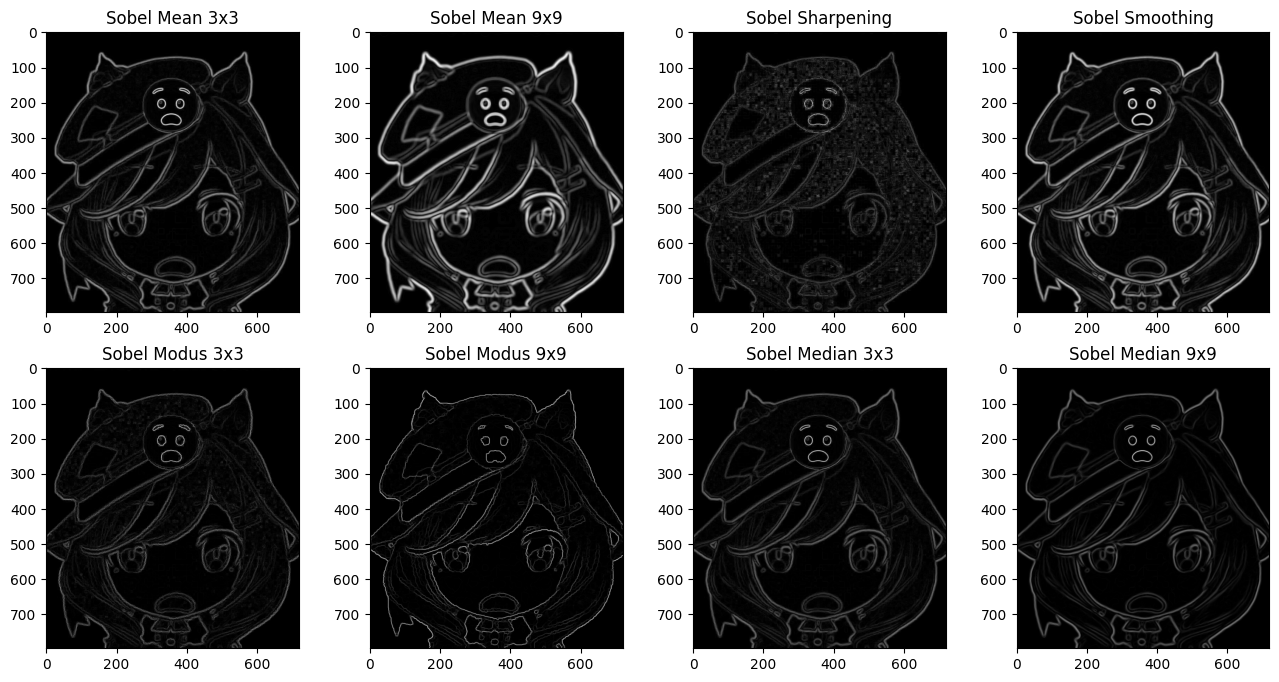

In [ ]:
sobel_mean_3x3 = deteksi_tepi(mean3x3, Sx, Sy, "sobel")
sobel_mean_9x9 = deteksi_tepi(mean9x9, Sx, Sy, "sobel")
sobel_sharpening = deteksi_tepi(sharpening, Sx, Sy, "sobel")
sobel_smoothing = deteksi_tepi(smoothing, Sx, Sy, "sobel")
sobel_modus_3x3 = deteksi_tepi(modus3x3, Sx,Sy, "sobel")
sobel_modus_9x9 = deteksi_tepi(modus9x9, Sx, Sy, "sobel")
sobel_median_3x3 = deteksi_tepi(median3x3, Sx, Sy, "sobel")
sobel_median_9x9 = deteksi_tepi(median9x9, Sx, Sy, "sobel")

plt.figure(figsize=(16,8))
plt.subplot(2,4,1)
plt.imshow(sobel_mean_3x3, cmap='gray')
plt.title('Sobel Mean 3x3')
plt.subplot(2,4,2)
plt.imshow(sobel_mean_9x9, cmap='gray')
plt.title('Sobel Mean 9x9')
plt.subplot(2,4,3)
plt.imshow(sobel_sharpening, cmap='gray')
plt.title('Sobel Sharpening')
plt.subplot(2,4,4)
plt.imshow(sobel_smoothing, cmap='gray')
plt.title('Sobel Smoothing')
plt.subplot(2,4,5)
plt.imshow(sobel_modus_3x3, cmap='gray')
plt.title('Sobel Modus 3x3')
plt.subplot(2,4,6)
plt.imshow(sobel_modus_9x9, cmap='gray')
plt.title('Sobel Modus 9x9')
plt.subplot(2,4,7)
plt.imshow(sobel_median_3x3, cmap='gray')
plt.title('Sobel Median 3x3')
plt.subplot(2,4,8)
plt.imshow(sobel_median_9x9, cmap='gray')
plt.title('Sobel Median 9x9')

Text(0.5, 1.0, 'Roberts Median 9x9')

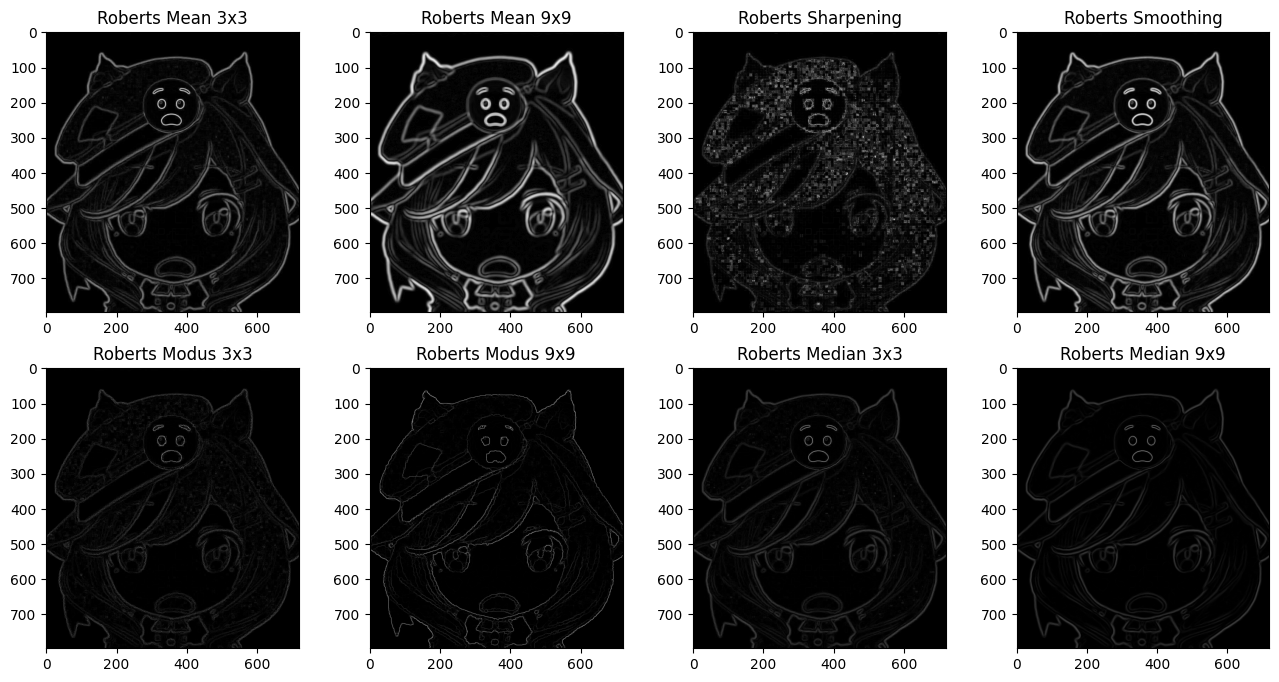

In [ ]:
roberts_mean_3x3 = deteksi_tepi(mean3x3, Rt, Rk, "roberts")
roberts_mean_9x9 = deteksi_tepi(mean9x9, Rt, Rk, "roberts")
roberts_sharpening = deteksi_tepi(sharpening, Rt, Rk, "roberts")
roberts_smoothing = deteksi_tepi(smoothing, Rt, Rk, "roberts")
roberts_modus_3x3 = deteksi_tepi(modus3x3, Rt, Rk, "roberts")
roberts_modus_9x9 = deteksi_tepi(modus9x9, Rt, Rk, "roberts")
roberts_median_3x3 = deteksi_tepi(median3x3, Rt, Rk, "roberts")
roberts_median_9x9 = deteksi_tepi(median9x9, Rt, Rk, "roberts")

plt.figure(figsize=(16,8))
plt.subplot(2,4,1)
plt.imshow(roberts_mean_3x3, cmap='gray')
plt.title('Roberts Mean 3x3')
plt.subplot(2,4,2)
plt.imshow(roberts_mean_9x9, cmap='gray')
plt.title('Roberts Mean 9x9')
plt.subplot(2,4,3)
plt.imshow(roberts_sharpening, cmap='gray')
plt.title('Roberts Sharpening')
plt.subplot(2,4,4)
plt.imshow(roberts_smoothing, cmap='gray')
plt.title('Roberts Smoothing')
plt.subplot(2,4,5)
plt.imshow(roberts_modus_3x3, cmap='gray')
plt.title('Roberts Modus 3x3')
plt.subplot(2,4,6)
plt.imshow(roberts_modus_9x9, cmap='gray')
plt.title('Roberts Modus 9x9')
plt.subplot(2,4,7)
plt.imshow(roberts_median_3x3, cmap='gray')
plt.title('Roberts Median 3x3')
plt.subplot(2,4,8)
plt.imshow(roberts_median_9x9, cmap='gray')
plt.title('Roberts Median 9x9')